# 01 — Data Exploration and Quality Audit

In [1]:
from pathlib import Path
import json
import os
import sys

def find_project_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "src").is_dir() and (candidate / "configs").is_dir():
            return candidate
    for base in (Path("/kaggle/working"), Path("/kaggle/input")):
        if base.exists():
            matches = list(base.glob("**/configs/ieee_cis.yaml"))
            if matches:
                return matches[0].parents[1]
    raise FileNotFoundError("Project root with src/ and configs/ was not found")

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

QUICK_RUN = os.getenv("THESIS_QUICK_RUN", "1") == "1"
ALLOW_SYNTHETIC_FALLBACK = os.getenv("THESIS_SYNTHETIC_FALLBACK", "1") == "1"
KAGGLE = Path("/kaggle").exists()
OUTPUT_BASE = Path("/kaggle/working/thesis_outputs") if KAGGLE else PROJECT_ROOT / "results/runs/notebooks"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 120)
print({"project_root": str(PROJECT_ROOT), "quick_run": QUICK_RUN, "kaggle": KAGGLE})

{'project_root': 'E:\\Study\\Thực tập tốt nghiệp\\Explainable_NeuroSymbolic_Fraud_Detection', 'quick_run': True, 'kaggle': False}


## Thiết lập

- IEEE-CIS `TransactionDT` provides an ordering proxy, not a real calendar timestamp.
- Preprocessing statistics must be fitted on train only.
- Quick mode limits rows for runtime validation.

In [2]:
from src.data import (
    load_config,
    load_fraud_dataframe,
    make_synthetic_fraud_data,
    prepare_dataset,
)

CONFIG_PATH = PROJECT_ROOT / "configs/ieee_cis.yaml"
config = load_config(CONFIG_PATH)
output_dir = OUTPUT_BASE / "01_data_exploration"
output_dir.mkdir(parents=True, exist_ok=True)
max_rows = 12000 if QUICK_RUN else None
try:
    frame = load_fraud_dataframe(config, max_rows=max_rows)
    data_source = "real"
except FileNotFoundError:
    if not ALLOW_SYNTHETIC_FALLBACK:
        raise
    frame = make_synthetic_fraud_data(max_rows or 6000, seed=config["project"]["seed"])
    data_source = "synthetic"
print({"data_source": data_source, "rows": len(frame), "columns": frame.shape[1]})
display(frame.head())

{'data_source': 'synthetic', 'rows': 12000, 'columns': 11}


,TransactionID,TransactionDT,TransactionAmt,transaction_hour,transaction_day,transaction_amount_log,C1,card1,DeviceType,P_emaildomain,isFraud
0,1,444,44.912542,0,0,3.826738,3,1460,desktop,NaN,0
1,2,524,11.704998,0,0,2.541995,3,1454,NaN,risk.example,0
2,3,1295,70.137051,0,0,4.264608,3,1619,desktop,mail.net,0
3,4,2050,84.822829,0,0,4.452285,2,1053,mobile,common.com,0
4,5,2716,4.706595,0,0,1.741623,1,1151,desktop,mail.net,0


## Data

In [3]:
target = config["dataset"]["target_column"]
time_column = config["dataset"]["time_column"]
summary = pd.DataFrame({
    "rows": [len(frame)],
    "columns": [frame.shape[1]],
    "fraud_count": [int(frame[target].sum())],
    "fraud_rate": [float(frame[target].mean())],
    "duplicate_rows": [int(frame.duplicated().sum())],
    "data_source": [data_source],
})
display(summary)

missing = frame.isna().mean().sort_values(ascending=False).rename("missing_fraction").to_frame()
display(missing.head(20))

,rows,columns,fraud_count,fraud_rate,duplicate_rows,data_source
0,12000,11,302,0.025167,0,synthetic


,missing_fraction
P_emaildomain,0.249333
DeviceType,0.050917
TransactionID,0.000000
TransactionAmt,0.000000
TransactionDT,0.000000
transaction_hour,0.000000
transaction_day,0.000000
C1,0.000000
transaction_amount_log,0.000000
card1,0.000000


In [4]:
prepared = prepare_dataset(frame, config)
split_summary = pd.DataFrame([
    {"split": "train", "rows": len(prepared.y_train), "fraud_rate": prepared.y_train.mean(),
     "time_min": prepared.train_frame[time_column].min(), "time_max": prepared.train_frame[time_column].max()},
    {"split": "validation", "rows": len(prepared.y_validation), "fraud_rate": prepared.y_validation.mean(),
     "time_min": prepared.validation_frame[time_column].min(), "time_max": prepared.validation_frame[time_column].max()},
    {"split": "test", "rows": len(prepared.y_test), "fraud_rate": prepared.y_test.mean(),
     "time_min": prepared.test_frame[time_column].min(), "time_max": prepared.test_frame[time_column].max()},
])
display(split_summary)
print({"selected_features": len(prepared.feature_names), "matrix_shape": prepared.X_train.shape})

,split,rows,fraud_rate,time_min,time_max
0,train,8400,0.024881,444,7294262
1,validation,1800,0.029444,7296771,8883771
2,test,1800,0.022222,8883848,10367740


{'selected_features': 8, 'matrix_shape': (8400, 8)}


## Results

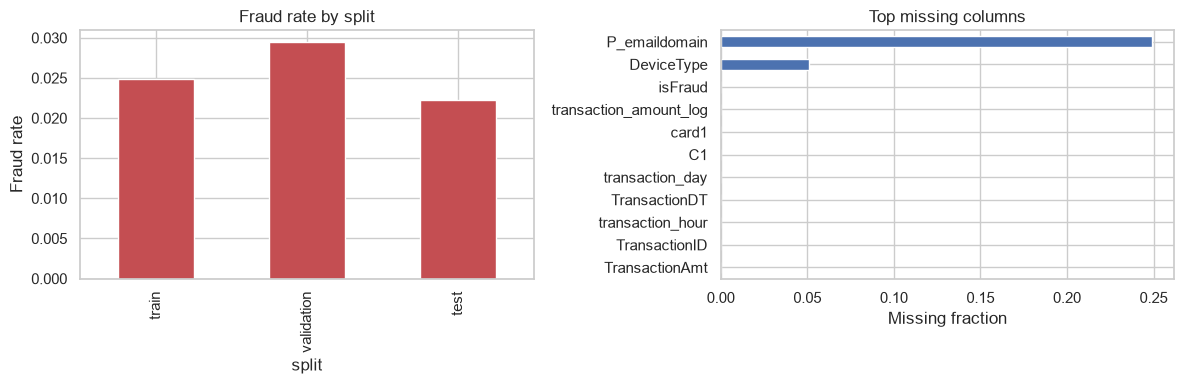

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
split_summary.plot.bar(x="split", y="fraud_rate", ax=axes[0], legend=False, color="#C44E52")
axes[0].set_title("Fraud rate by split")
axes[0].set_ylabel("Fraud rate")
missing.head(20).sort_values("missing_fraction").plot.barh(ax=axes[1], legend=False, color="#4C72B0")
axes[1].set_title("Top missing columns")
axes[1].set_xlabel("Missing fraction")
plt.tight_layout()
fig.savefig(output_dir / "data_quality_overview.png", dpi=160, bbox_inches="tight")
plt.show()

summary.to_csv(output_dir / "dataset_summary.csv", index=False)
split_summary.to_csv(output_dir / "split_summary.csv", index=False)
missing.to_csv(output_dir / "missingness.csv")

## Takeaways

In [6]:
display(Markdown(
    f"- Data source: **{data_source}** with **{len(frame):,}** rows and **{frame.shape[1]}** columns.\n"
    f"- Overall fraud rate: **{frame[target].mean():.4%}**.\n"
    f"- Preprocessor retained **{len(prepared.feature_names)}** train-fitted features.\n"
    f"- Temporal order check: **{prepared.train_frame[time_column].max() <= prepared.validation_frame[time_column].min() <= prepared.test_frame[time_column].min()}**."
))

- Data source: **synthetic** with **12,000** rows and **11** columns.
- Overall fraud rate: **2.5167%**.
- Preprocessor retained **8** train-fitted features.
- Temporal order check: **True**.